# LIBRA BABY 1L and Lithium Oxide (Li2O) Powder Bed Blanket


In [3]:
import math
import openmc
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap
from openmc_LiOx_powder import baby_model

**Li2O packed bed properties**
Pellet porosity: 0.0 %
Packing efficiency: 64.0 %
Pellet bed density: 1.2883399174578718 g/cm3
Oxygen mass fraction: 0.535466955938528 % mass
Lithium mass fraction: 0.464517584276673 % mass
Helium mass fraction: 1.545978479905476e-05 % mass


### Geometry

In [4]:
model = baby_model()
geometry = model.geometry

isotopes ['Al27', 'Ar36', 'Ar38', 'Ar40', 'B10', 'B11', 'Be9', 'C12', 'C13', 'Ca40', 'Ca42', 'Ca43', 'Ca44', 'Ca46', 'Ca48', 'Co59', 'Cr50', 'Cr52', 'Cr53', 'Cr54', 'Cu63', 'Cu65', 'F19', 'Fe54', 'Fe56', 'Fe57', 'Fe58', 'H1', 'H2', 'He3', 'He4', 'K39', 'K40', 'K41', 'Li6', 'Li7', 'Mg24', 'Mg25', 'Mg26', 'Mn55', 'Mo100', 'Mo92', 'Mo94', 'Mo95', 'Mo96', 'Mo97', 'Mo98', 'N14', 'N15', 'Na23', 'Nb93', 'Ni58', 'Ni60', 'Ni61', 'Ni62', 'Ni64', 'O16', 'O17', 'O18', 'P31', 'Pb204', 'Pb206', 'Pb207', 'Pb208', 'S32', 'S33', 'S34', 'S36', 'Si28', 'Si29', 'Si30', 'Ti46', 'Ti47', 'Ti48', 'Ti49', 'Ti50', 'W182', 'W183', 'W184', 'W186', 'Zr90', 'Zr91', 'Zr92', 'Zr94', 'Zr96']
Searching libraries with the following priority {'ENDFB-8.0-NNDC': 1}
Isotopes found matching library requirements 556
Isotopes found matching particle requirements 1789
Isotopes found matching isotope requirements 337
Isotopes found matching all requirements 85
             library remote_file  \
1233  ENDFB-8.0-NNDC       H1.h5 

### Vault Geometry

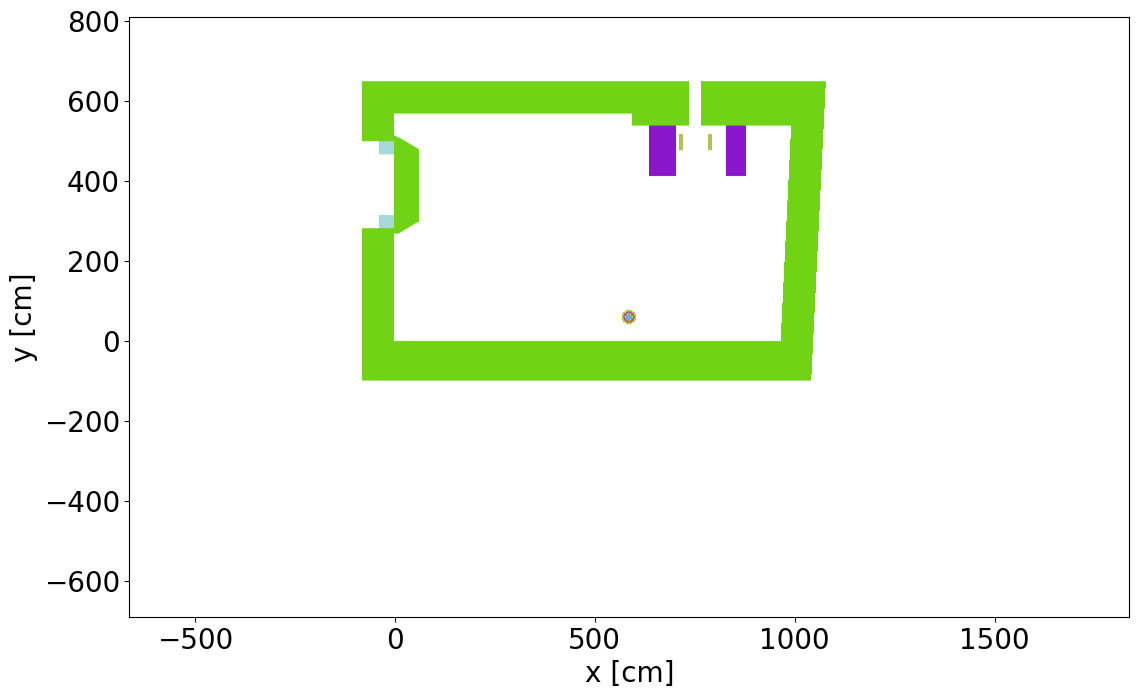

In [5]:
# Visualization

from libra_toolbox.neutronics.vault import Air
from openmc_LiOx_powder import air, x_c, y_c, z_c

ax = geometry.plot(
    width=(2500, 1500),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.show()

### BABY 1L Geometry XZ View

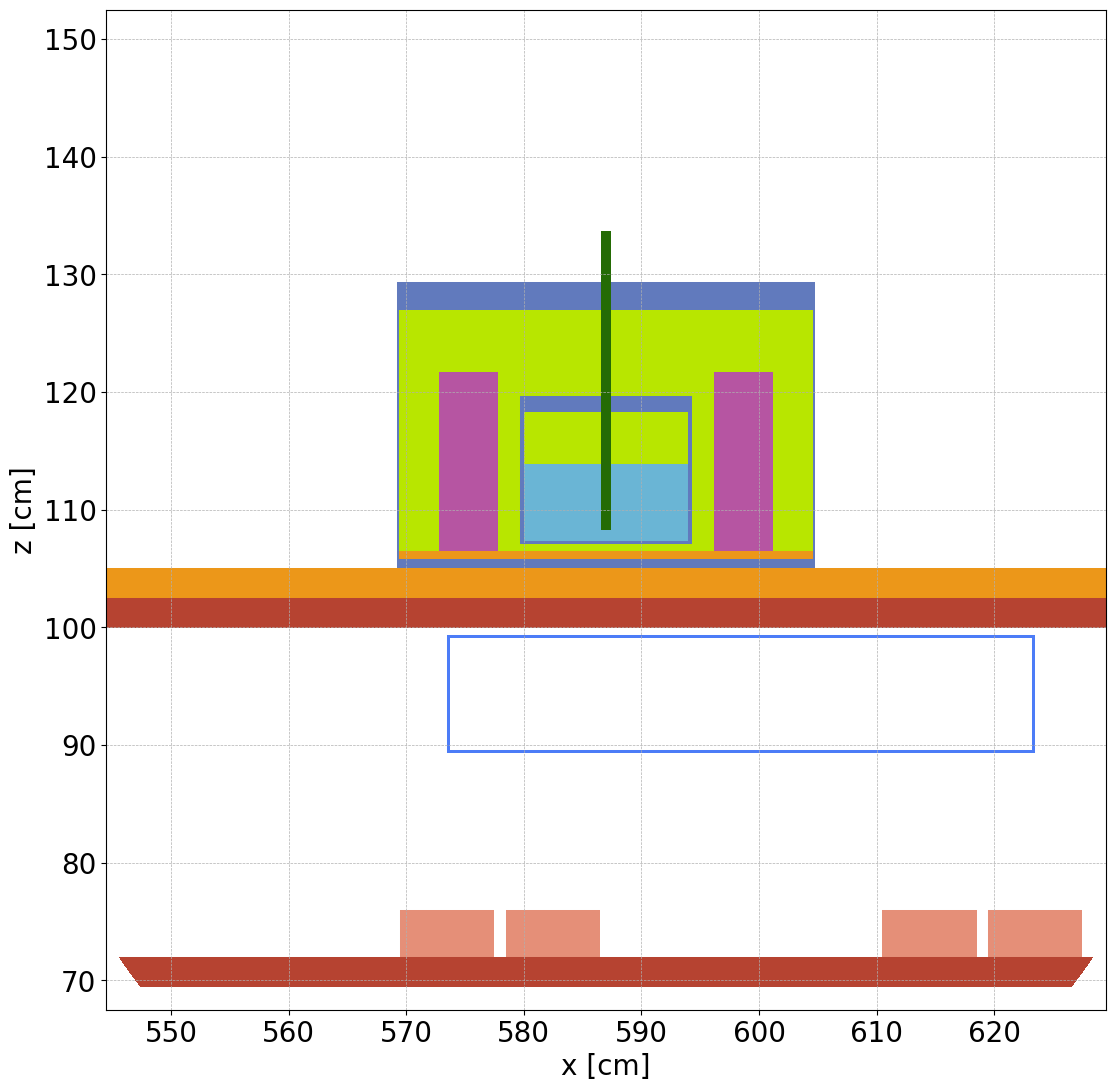

In [6]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xz",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### BABY 1L Geometry YZ View

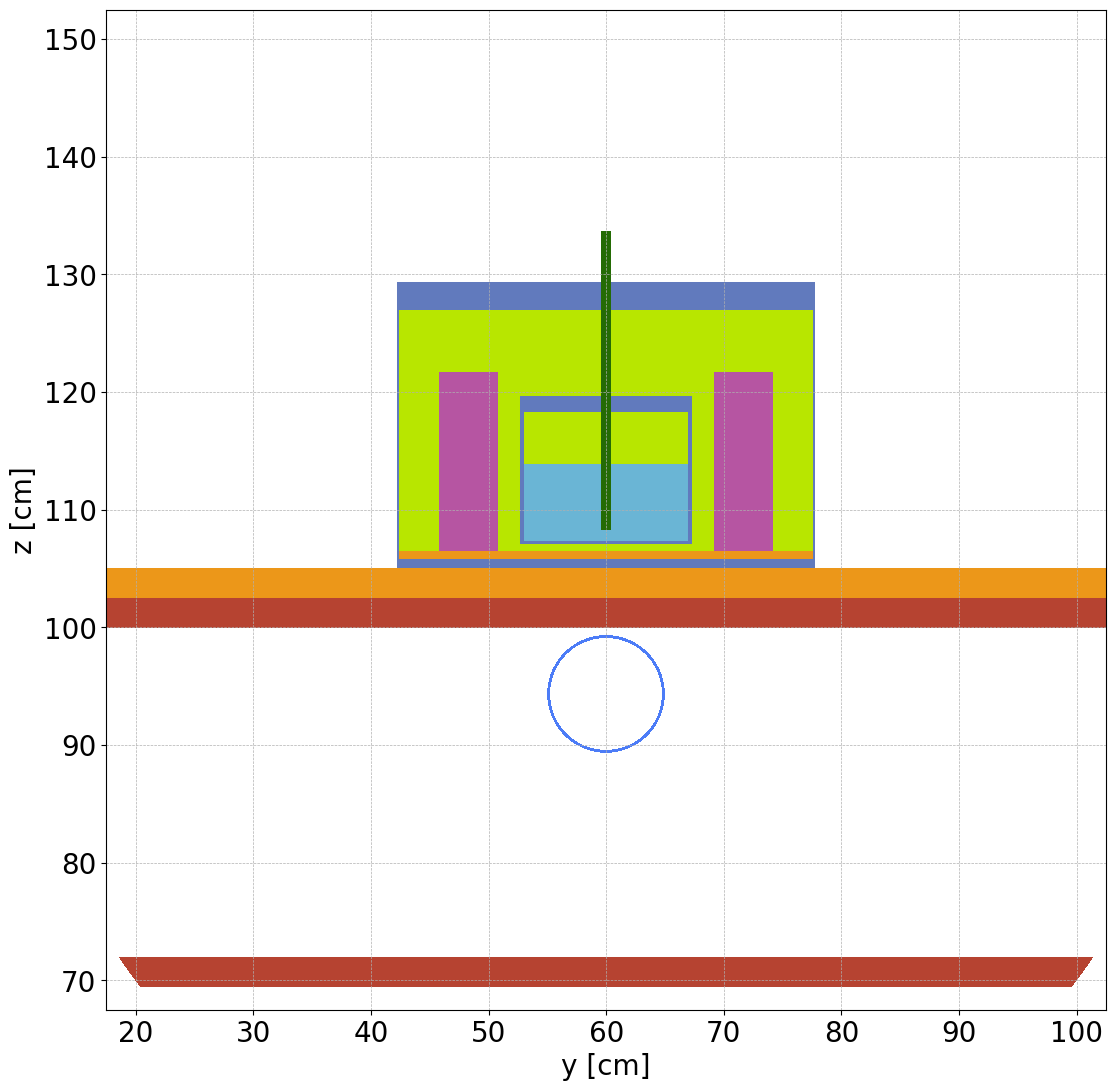

In [7]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="yz",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### BABY 1L Geometry XY View

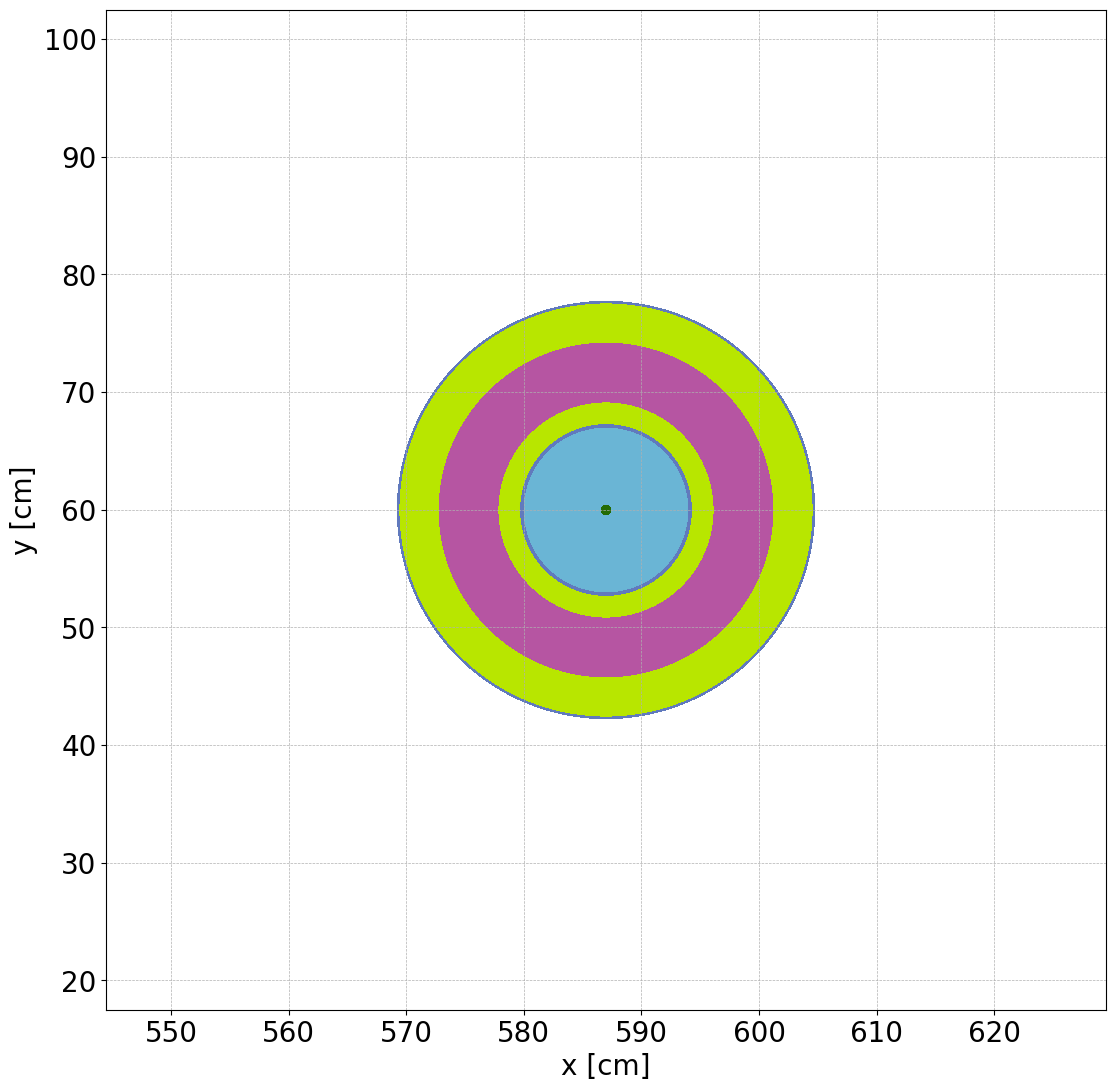

In [8]:
ax = geometry.plot(
    width=(85, 85),
    origin=(x_c, y_c, z_c + 10),
    pixels=(1000, 1000),
    basis="xy",
    color_by="material",
    colors={Air: "white", air: "white"},
)
ax.tick_params(axis="both", labelsize=20)
ax.set_xlabel(ax.get_xlabel(), fontsize=20)
ax.set_ylabel(ax.get_ylabel(), fontsize=20)
plt.grid(visible=True, which='both', linestyle='--', linewidth=0.5)  # Add gridlines
plt.show()

### Spatial Distribution Results

In [9]:
from openmc_LiOx_powder import Li2O_bed_radius, Li2O_bed_thickness, heater_gap, heater_radius, packing_efficiency, mesh
# Load the statepoint file
sp = openmc.StatePoint("LiOx_powder_results.h5")

if mesh == 1:
    import matplotlib.colors as mcolors
    import matplotlib.patches as patches
    import vtk

    # Get the tally object from the statepoint file
    tally_mesh = sp.get_tally(name="TBR_mesh")

    # Get pandas dataframe for the cell tally data
    df = tally_mesh.get_pandas_dataframe()

    # Get the mesh object from the tally filters
    mesh = None
    for f in tally_mesh.filters:
        if isinstance(f, openmc.MeshFilter):
            mesh = f.mesh
            print(type(mesh))
            break

    if mesh is None:
        raise ValueError("No mesh filter found in the tally!")

    if mesh is not None:

        # Extract the number of bins for each dimension from the mesh
        n_r = len(mesh.r_grid) - 1  # Radial bins
        n_phi = len(mesh.phi_grid) - 1  # Angular binss
        n_z = len(mesh.z_grid) - 1  # Axial bins

        # Convert mean TBR values to NumPy array
        mean_array = df['mean'].values.reshape((n_z, n_phi, n_r))

        # Convert std dev values to NumPy array
        stdev_array = df['std. dev.'].values.reshape((n_z, n_phi, n_r))

        ### Export vtk of mesh results ###
        datasets = {
        "mean_vol_TBR": mean_array,
        "mean_bulk_vol_TBR": mean_array / packing_efficiency,
        }
        mesh.write_data_to_vtk("tally_mesh_data_LiOx_powder.vtk", datasets, volume_normalization=True) # True = use built-in data normalisation

        print("Mesh tally data exported to tally_mesh_data_LiOx_powder.vtk")

        # Reshape the mean and standard deviation arrays to 2D for plotting by collapsing angular bins
        # Combine the standard deviation over angular bins when collapsing the angular dimension
        stdev_array_combined = np.sqrt(np.sum(stdev_array**2, axis=1))

        # Get the cell volumes from the mesh object
        mesh_volumes = mesh.volumes
        # Sum all angular bins for each r and z bin
        mean_array_summed = np.sum(mean_array, axis=1)
        volume_array_summed = np.sum(mesh_volumes, axis=1)

        # Reshape cell volumes to match the shape of the tally data
        volume_array_summed = np.squeeze(volume_array_summed).transpose()

        # Calculate volumetric TBR by dividing mean TBR by cell volumes
        vol_tbr_array = mean_array_summed / volume_array_summed

        # Calculate TBR in bulk Li2O by dividing volumetric TBR by packing efficiency
        bulk_vol_tbr_array = vol_tbr_array / packing_efficiency

        # Divide the standard deviation values by the mean values to get the relative standard deviation for plotting below
        rel_std_dev_array = stdev_array_combined / mean_array_summed

        #### Plot local TBR values ####

        fig, ax = plt.subplots()
    
        im = ax.imshow(
            mean_array_summed,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(mean_array_summed[mean_array_summed > 0])*0.8), vmax=(np.max(mean_array_summed))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('TBR (T/n)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(mean_array_summed):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Absolute TBR (LiOx bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local volumetric TBR ####
        
        fig, ax = plt.subplots()
    
        im = ax.imshow(
            vol_tbr_array,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(vol_tbr_array[vol_tbr_array > 0]))*0.8, vmax=(np.max(vol_tbr_array))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Volumetric TBR (T/n/cm3)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(vol_tbr_array):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Volumetric TBR (LiOx bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local bulk volumetric TBR ####
        
        fig, ax = plt.subplots()
    
        im = ax.imshow(
            bulk_vol_tbr_array,
            interpolation='nearest',
            extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
            origin='lower',
            aspect='auto',
            norm=mcolors.LogNorm(vmin=(np.min(bulk_vol_tbr_array[vol_tbr_array > 0]))*0.8, vmax=(np.max(bulk_vol_tbr_array))*1.2),  # Use LogNorm for logarithmic scale
            cmap='viridis'  # You can change the colormap if desired
        )
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Volumetric TBR (T/n/cm3)', fontsize=12)
        cbar.ax.text(1.1, 1.0, f"Max: {np.max(bulk_vol_tbr_array):.2e}", transform=cbar.ax.transAxes, ha='left', va='center')
        ax.set_title('Local Bulk Volumetric TBR (LiOx bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')


        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

        #### Plot local TBR relative standard deviation values ####

        fig, ax = plt.subplots()

        im = ax.imshow(
        rel_std_dev_array,
        interpolation='nearest',
        extent=[0, Li2O_bed_radius, 0, Li2O_bed_thickness],
        origin='lower',
        aspect='auto',
        norm=mcolors.LogNorm(vmin=1e-3, vmax=1),  # Use LogNorm for logarithmic scale
        cmap='viridis'
        )
        
        cbar = plt.colorbar(im, ax=ax)
        ax.set_title('Local TBR relative standard deviation (LiOx bed X-section)')
        ax.set_xlabel('Radial pos (cm)')
        ax.set_ylabel('Axial pos (cm)')

        # Add a rectangle outlining the heater region
        heater_rect = patches.Rectangle(
            (0, heater_gap),  # (x, y) lower left corner
            heater_radius,  # width
            (Li2O_bed_thickness-heater_gap),  # height
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(heater_rect)

        # Add a label
        ax.text(
            heater_radius/2, Li2O_bed_thickness/2,  # position in the center of the rectangle
            'Heater',
            color='black',
            fontsize=12,
            ha='center',
            va='center',
            rotation=90
        )
        plt.show()

### Global TBR Results

In [10]:
tally = sp.get_tally(name="TBR").get_pandas_dataframe()

mean = tally["mean"].iloc[0]  # Extract the first value
stdev = tally["std. dev."].iloc[0]  # Extract the first value

# Print the global TBR results
print(f"Global TBR: {mean:.6e}")
print(f"Global TBR Standard Deviation: {stdev:.6e}")

rel_stdev = stdev / mean

print(f"Relative standard deviation: {rel_stdev:.6e}\n")
print("Relative standard deviation below 1e-02 (1%) indicates good convergence.")

Global TBR: 4.110670e-03
Global TBR Standard Deviation: 3.750201e-05
Relative standard deviation: 9.123091e-03

Relative standard deviation below 1e-02 (1%) indicates good convergence.
